In [12]:
import pandas as pd
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [14]:
error_cols = ["error_problem", "error_solver", "error_type"]
raw_df = pd.read_csv("./datasets/new_raw.csv")

In [15]:
df = pd.read_csv("./datasets/final.csv")
df.columns

Index(['nvmops', 'objective', 'eval_duration_solver',
       'extract_duration_solver', 'stats_elapsed_time', 'name', 'dual_feas',
       'status', 'timed_bytes', 'timed_time', 'timed_gctime',
       'nlp_warmup_time', 'mem', 'neval_grad', 'iter', 'source_solver', 'nvar',
       'problem', 'neval_obj', 'timestamp_solver', 'error_solver',
       'vector_type', 'extract_duration_problem', 'highest_degree (ExprTree)',
       'nln_nnzj', 'adbackend_hessian_backend_type', 'minimize',
       'count_plus_minus', 'alloc_obj', 'jtprod_available', 'has_equalities',
       'time_hprod', 'adbackend_jprod_residual_backend_type',
       'adbackend_ghjvprod_backend_type', 'nnln', 'jprod_residual_available',
       'nlvb', 'nlvo', 'nlp_type', 'unconstrained',
       'adbackend_jacobian_backend_type', 'adbackend_jprod_backend_type',
       'hprod_residual_available', 'jac_available', 'hess_residual_available',
       'adbackend_gradient_backend_type', 'float_type', 'ncon', 'is_nls',
       'nnzo', 'nlv

In [16]:
data = pd.read_csv("./datasets/new_raw.csv")
data[data["status"].notna()]
data["status"].value_counts()

status
first_order    21487
time_limit       315
Name: count, dtype: int64

In [17]:
list(data.columns)

['nvmops',
 'objective',
 'eval_duration_solver',
 'extract_duration_solver',
 'stats_elapsed_time',
 'name',
 'dual_feas',
 'status',
 'timed_bytes',
 'timed_time',
 'timed_gctime',
 'nlp_warmup_time',
 'mem',
 'neval_grad',
 'iter',
 'source_solver',
 'nvar',
 'problem',
 'neval_obj',
 'timestamp_solver',
 'error_solver',
 'vector_type',
 'extract_duration_problem',
 'highest_degree (ExprTree)',
 'nln_nnzj',
 'adbackend_hessian_backend_type',
 'minimize',
 'count_plus_minus',
 'alloc_obj',
 'jtprod_available',
 'has_equalities',
 'time_hprod',
 'adbackend_jprod_residual_backend_type',
 'adbackend_ghjvprod_backend_type',
 'nnln',
 'jprod_residual_available',
 'nlvb',
 'nlvo',
 'nlp_type',
 'unconstrained',
 'adbackend_jacobian_backend_type',
 'adbackend_jprod_backend_type',
 'hprod_residual_available',
 'jac_available',
 'hess_residual_available',
 'adbackend_gradient_backend_type',
 'float_type',
 'ncon',
 'is_nls',
 'nnzo',
 'nlvc',
 'tree_length',
 'count_trigonometric_function',
 

In [18]:
meta_df = pd.read_csv("./datasets/problem_metadata.csv")
meta_df.head(10)
len(list(meta_df.columns))

78

In [19]:
solver_df = pd.read_csv("./datasets/solver_runtimes.csv")
solver_df.head(10)
len(list(solver_df.columns))

21

In [20]:
data["name"]

0         dqdrtic
1         dqdrtic
2         dqdrtic
3         dqdrtic
4         dqdrtic
           ...   
21797    srosenbr
21798    srosenbr
21799    srosenbr
21800    srosenbr
21801    srosenbr
Name: name, Length: 21802, dtype: object

## Get a sense of how many problems are left unsolved

In [21]:
bins = [0, 95, 100, 1_000, 10_000, 100_000, 500_000]
data["nvar_bin"] = pd.cut(data["nvar"], bins=bins)
bin_counts = data["nvar_bin"].value_counts().sort_index()
print(bin_counts)

nvar_bin
(0, 95]                0
(95, 100]           7604
(100, 1000]         7416
(1000, 10000]       4577
(10000, 100000]     2205
(100000, 500000]       0
Name: count, dtype: int64


## Timeout is the main cause of error. We will assign it with the maxtime

In [22]:
g = error_df.groupby(["name", "nvar"])

summary = g.agg(
    mem_tried=("mem", "nunique"),
    n_failed=("error_solver", lambda s: s.notna().sum()),
    n_timeout=("error_solver", lambda s: s.astype(str).str.contains("timeout|max_time|time limit", case=False, na=False).sum()),
).reset_index()

summary["all_failed"] = summary["n_failed"] == summary["mem_tried"]
summary["all_timeout"] = summary["n_timeout"] == summary["mem_tried"]

# summary[summary["all_failed"]]
summary[summary["all_timeout"]].sum()

NameError: name 'error_df' is not defined

In [ ]:
error_df = pd.read_csv("error.csv")
error_df[error_cols]
error_df["error_type"].value_counts()

FileNotFoundError: [Errno 2] No such file or directory: 'error.csv'

In [ ]:
data["extract_duration_solver"].describe()

count    21802.000000
mean       231.156322
std        623.581489
min          0.010550
25%          0.028606
50%          1.111176
75%         38.399035
max       4836.617282
Name: extract_duration_solver, dtype: float64

In [ ]:
data["extract_duration_problem"].describe()

count    21802.000000
mean       917.739506
std       3005.186915
min          0.344133
25%          3.930943
50%         15.751056
75%        157.154165
max      29930.254929
Name: extract_duration_problem, dtype: float64

In [ ]:
data["stats_elapsed_time"].describe()

count    21802.000000
mean       282.321702
std        958.209320
min          0.000135
25%          0.017087
50%          1.099377
75%         38.387239
max       7200.000000
Name: stats_elapsed_time, dtype: float64

In [ ]:
data["eval_duration_solver"].describe() # time to instantiate the problem

count    21802.000000
mean         0.303081
std          0.134064
min          0.000418
25%          0.267699
50%          0.309126
75%          0.365034
max          0.829645
Name: eval_duration_solver, dtype: float64

In [ ]:
data["eval_duration_problem"].describe() # time to instantiate before problem and extract features

count    21802.000000
mean         2.660228
std          1.879221
min          0.011663
25%          0.865562
50%          3.130428
75%          3.688310
max          9.299191
Name: eval_duration_problem, dtype: float64

In [ ]:
col_lst = [column for column in data.columns]
# for col in col_lst:
#     print(col)
col_lst

['nvmops',
 'objective',
 'eval_duration_solver',
 'extract_duration_solver',
 'stats_elapsed_time',
 'name',
 'dual_feas',
 'status',
 'timed_bytes',
 'timed_time',
 'timed_gctime',
 'nlp_warmup_time',
 'mem',
 'neval_grad',
 'iter',
 'source_solver',
 'nvar',
 'problem',
 'neval_obj',
 'timestamp_solver',
 'error_solver',
 'vector_type',
 'extract_duration_problem',
 'highest_degree (ExprTree)',
 'nln_nnzj',
 'adbackend_hessian_backend_type',
 'minimize',
 'count_plus_minus',
 'alloc_obj',
 'jtprod_available',
 'has_equalities',
 'time_hprod',
 'adbackend_jprod_residual_backend_type',
 'adbackend_ghjvprod_backend_type',
 'nnln',
 'jprod_residual_available',
 'nlvb',
 'nlvo',
 'nlp_type',
 'unconstrained',
 'adbackend_jacobian_backend_type',
 'adbackend_jprod_backend_type',
 'hprod_residual_available',
 'jac_available',
 'hess_residual_available',
 'adbackend_gradient_backend_type',
 'float_type',
 'ncon',
 'is_nls',
 'nnzo',
 'nlvc',
 'tree_length',
 'count_trigonometric_function',
 

In [ ]:
success_counts = data.groupby("mem")["solved"].sum().sort_values(ascending=False)
success_counts

KeyError: 'Column not found: solved'

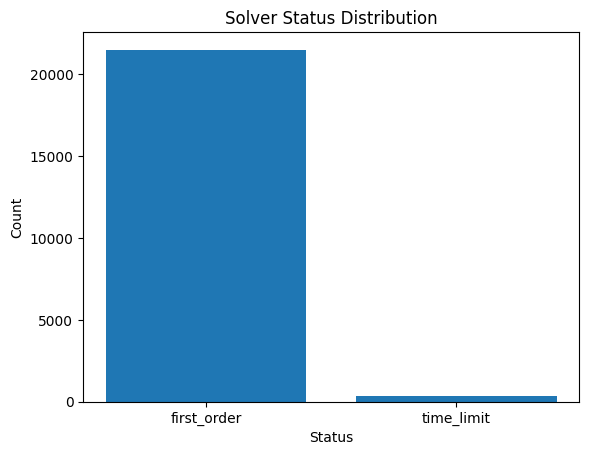

In [ ]:
status_counts = data["status"].value_counts()

plt.figure()
plt.bar(status_counts.index.astype(str), status_counts.values)
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Solver Status Distribution")
plt.show()

In [ ]:
data["stats_elapsed_time"].describe()

count    21802.000000
mean       282.321702
std        958.209320
min          0.000135
25%          0.017087
50%          1.099377
75%         38.387239
max       7200.000000
Name: stats_elapsed_time, dtype: float64

In [ ]:
data["is_constant (ExprTree)"].dropna().value_counts()

is_constant (ExprTree)
False    21802
Name: count, dtype: int64

In [ ]:
data["is_linear (ExprTree)"].value_counts()

is_linear (ExprTree)
False    21802
Name: count, dtype: int64

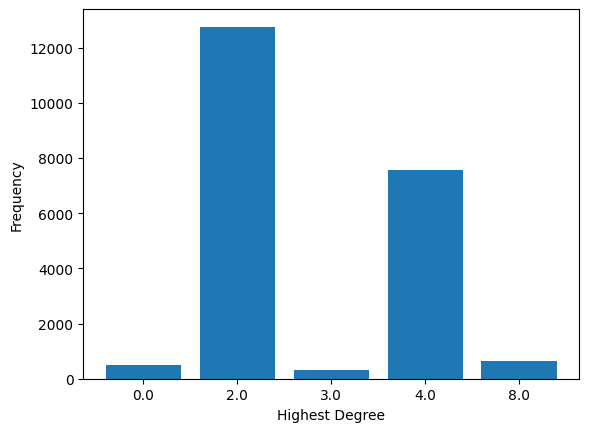

In [ ]:
x = data["highest_degree (ExprTree)"].dropna()
counts = x.value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Highest Degree")
plt.ylabel("Frequency")
plt.show()

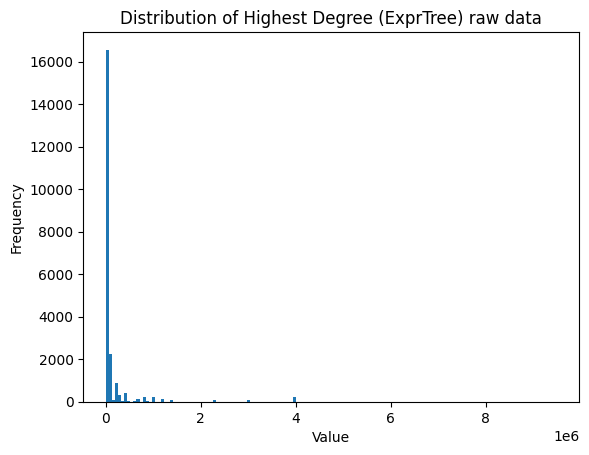

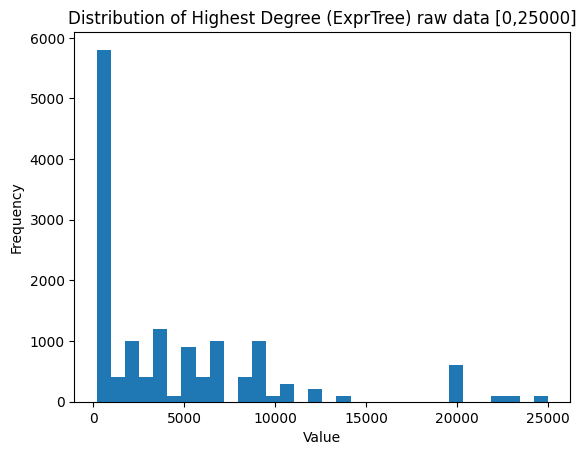

Text(0.5, 1.0, 'Log-scaled Distribution of Highest Degree (ExprTree) raw data')

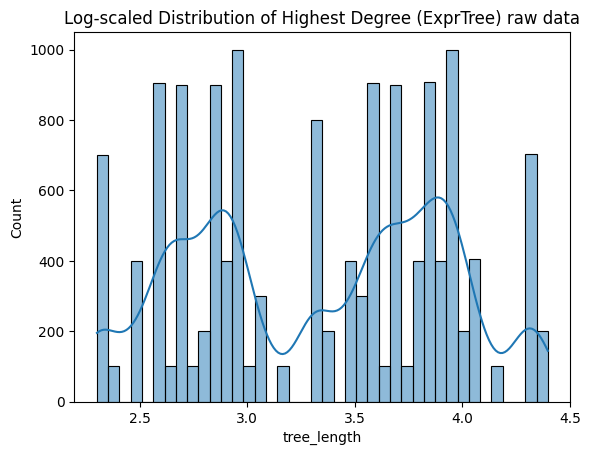

In [ ]:
x = data["tree_length"].dropna()
plt.figure()
plt.title("Distribution of Highest Degree (ExprTree) raw data")
plt.hist(x, bins="scott")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

x = data["tree_length"].dropna()
x = x[x <= 25000]
plt.figure()
plt.title("Distribution of Highest Degree (ExprTree) raw data [0,25000]")
plt.hist(x, bins="scott")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

ax = sns.histplot(np.log10(x), bins=40, kde=True)
ax.set_title("Log-scaled Distribution of Highest Degree (ExprTree) raw data")

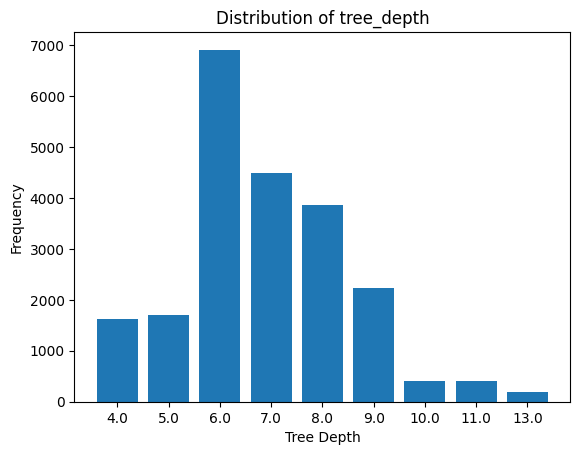

In [ ]:
x = data["tree_depth"].dropna()
counts = x.value_counts().sort_index()
plt.figure()
plt.title("Distribution of tree_depth")
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Tree Depth")
plt.ylabel("Frequency")
plt.show()

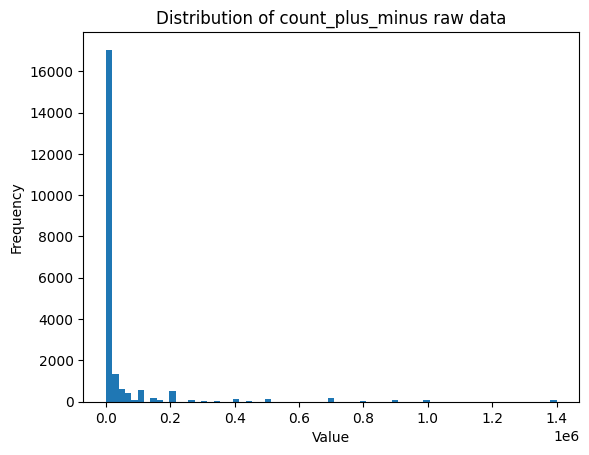

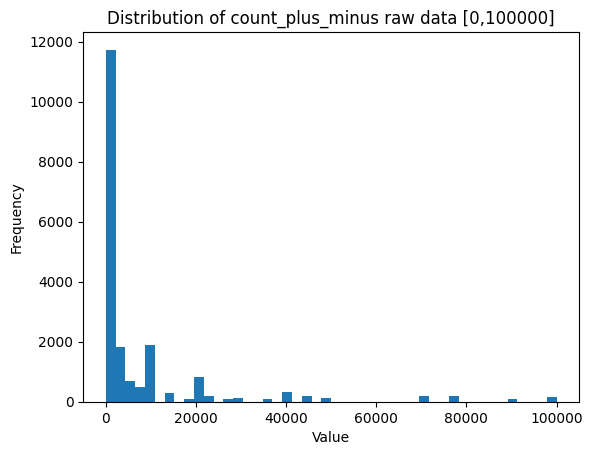

Text(0.5, 1.0, 'Log-scaled Distribution of count_plus_minus raw data')

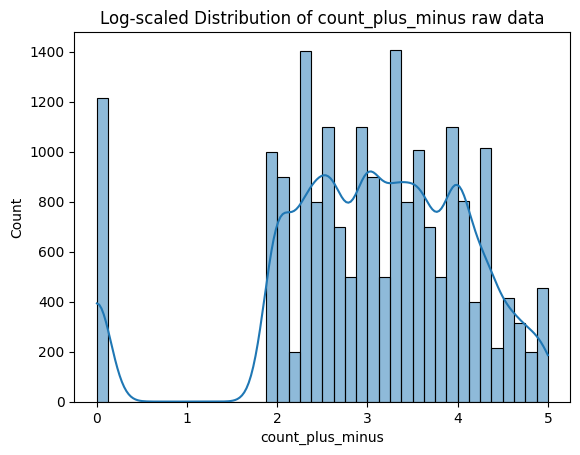

In [ ]:
x = data["count_plus_minus"].dropna()
plt.figure()
plt.title("Distribution of count_plus_minus raw data")
plt.hist(x, bins="scott")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

x = data["count_plus_minus"].dropna()
x = x[x <= 100000]
plt.figure()
plt.title("Distribution of count_plus_minus raw data [0,100000]")
plt.hist(x, bins="scott")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

ax = sns.histplot(np.log10(x), bins=40, kde=True)
ax.set_title("Log-scaled Distribution of count_plus_minus raw data")

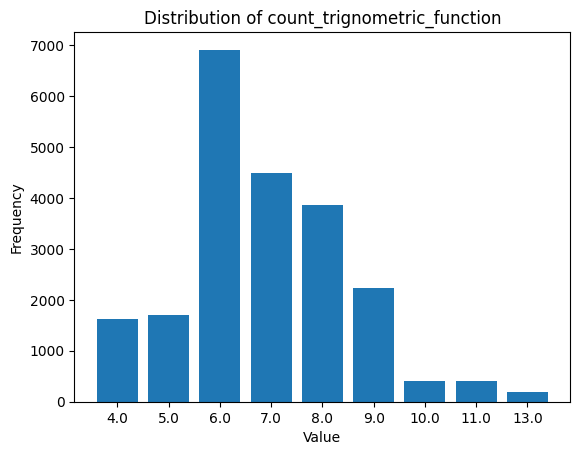

In [ ]:
x = data["count_trigonometric_function"].dropna()
count = x.value_counts().sort_index()
plt.title("Distribution of count_trignometric_function")
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

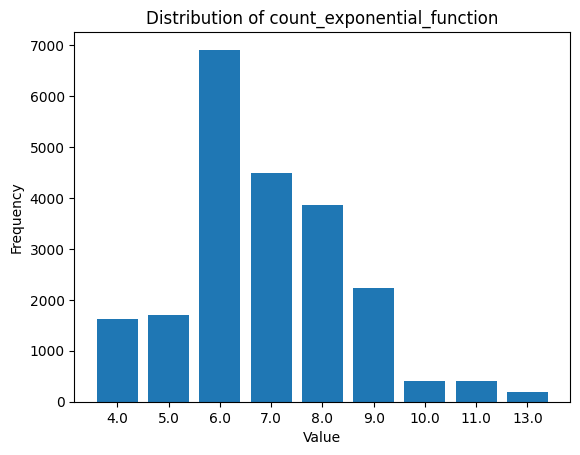

In [ ]:
x = data["count_exponential_function"].dropna()
count = x.value_counts().sort_index()
plt.title("Distribution of count_exponential_function")
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

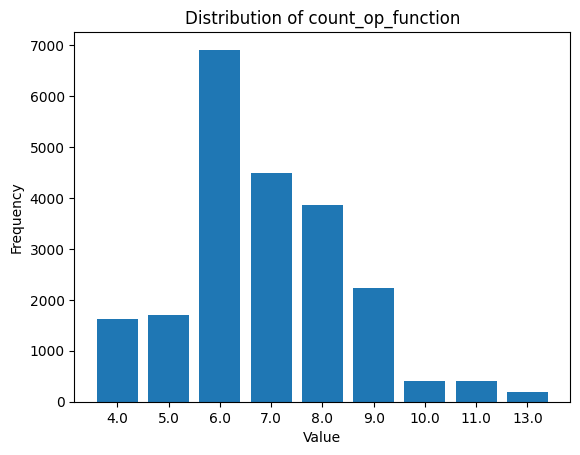

In [ ]:
x = data["count_op_function"].dropna()
count = x.value_counts().sort_index()
plt.title("Distribution of count_op_function")
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

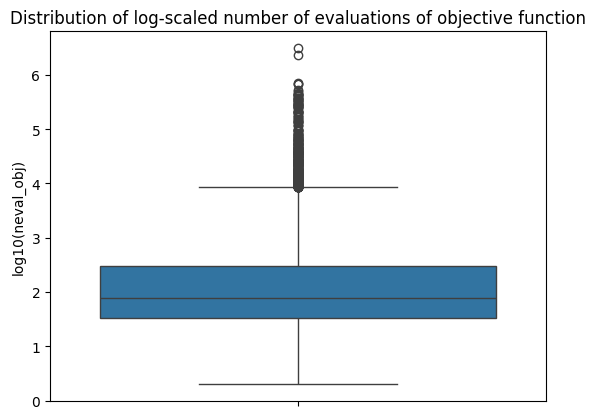

In [ ]:
x = data["neval_obj"].dropna()

sns.boxplot(y=np.log10(x))
plt.ylabel("log10(neval_obj)")
plt.title("Distribution of log-scaled number of evaluations of objective function")
plt.show()

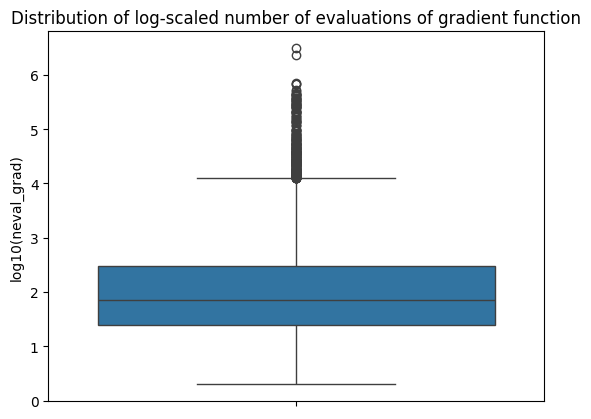

In [ ]:
x = data["neval_grad"].dropna()

sns.boxplot(y=np.log10(x))
plt.ylabel("log10(neval_grad)")
plt.title("Distribution of log-scaled number of evaluations of gradient function")
plt.show()

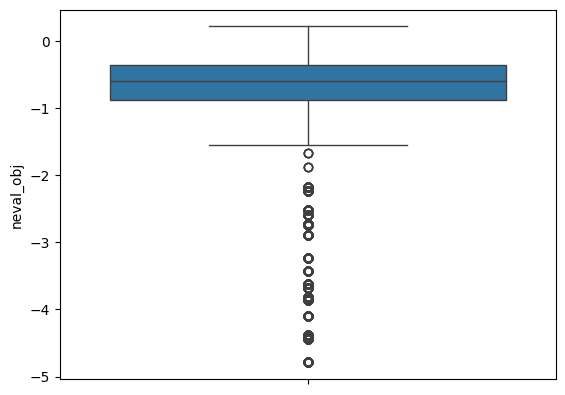

In [ ]:
x = data["time_obj"].dropna()

sns.boxplot(y=np.log10(x))
plt.ylabel("neval_obj")
plt.show()

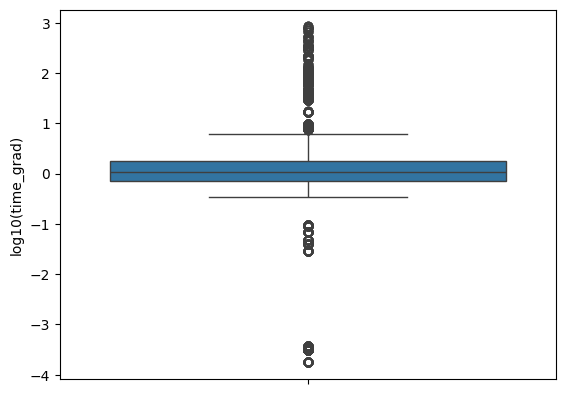

In [ ]:
x = data["time_grad"].dropna()

sns.boxplot(y=np.log10(x))
plt.ylabel("log10(time_grad)")
plt.show()

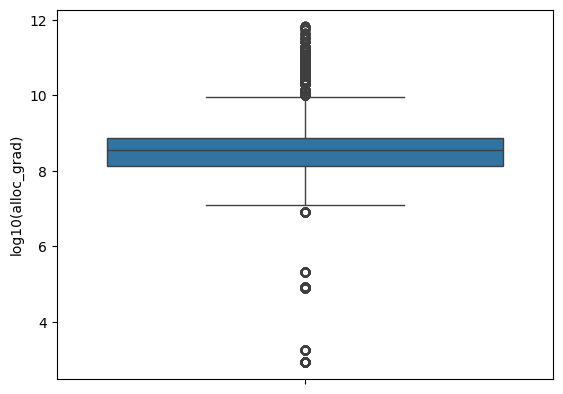

In [ ]:
x = data["alloc_grad"].dropna()
x = x[x > 0]

sns.boxplot(y=np.log10(x))
plt.ylabel("log10(alloc_grad)")
plt.show()

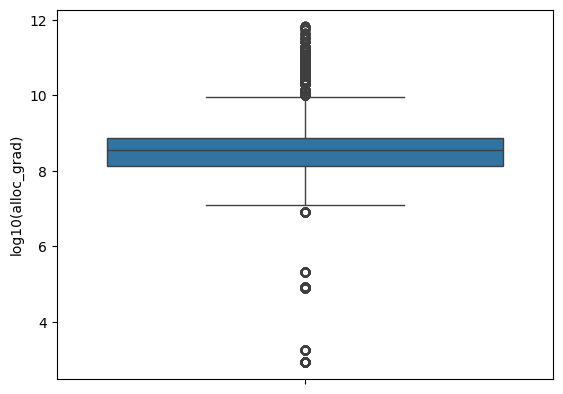

In [ ]:
x = data["alloc_grad"].dropna()
x = x[x > 0]

sns.boxplot(y=np.log10(x))
plt.ylabel("log10(alloc_grad)")
plt.show()

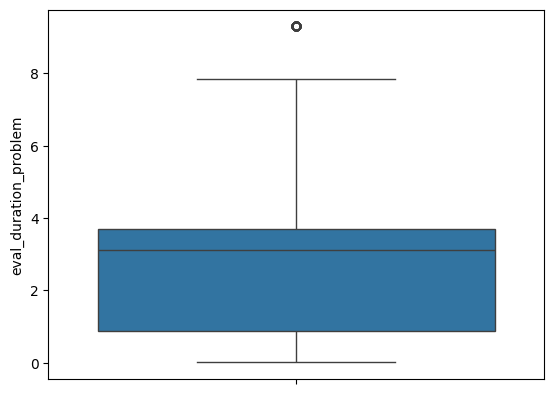

In [ ]:
x = data["eval_duration_problem"].dropna()

sns.boxplot(y=x)
plt.ylabel("eval_duration_problem")
plt.show()

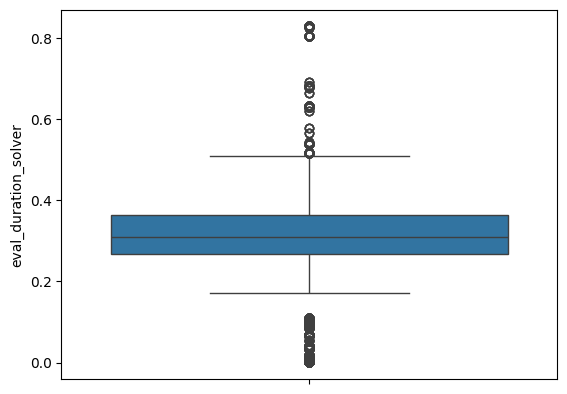

In [ ]:
x = data["eval_duration_solver"].dropna()
x = x[x > 0]

sns.boxplot(y=x)
plt.ylabel("eval_duration_solver")
plt.show()

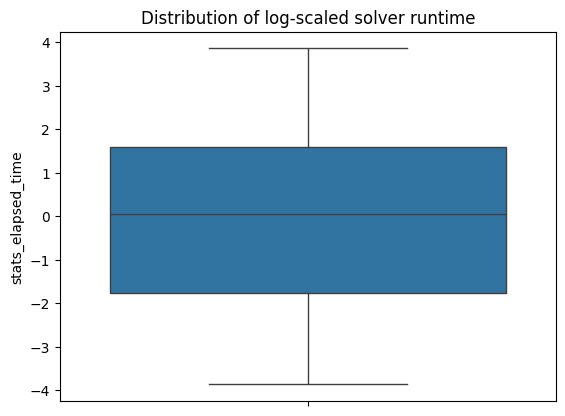

count    21802.000000
mean       282.321702
std        958.209320
min          0.000135
25%          0.017087
50%          1.099377
75%         38.387239
max       7200.000000
Name: stats_elapsed_time, dtype: float64

In [23]:
x = data["stats_elapsed_time"]
x = x[x>0]

sns.boxplot(y=np.log10(x))
plt.ylabel("stats_elapsed_time")
plt.title("Distribution of log-scaled solver runtime")
plt.show()

data["stats_elapsed_time"].describe()

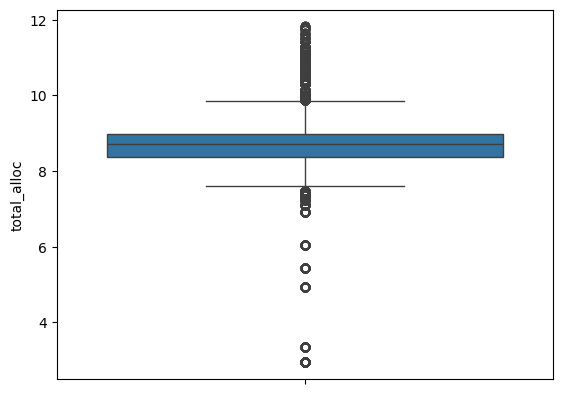

In [ ]:
x = data["total_alloc"]
x = x[x>0]
x.describe()

sns.boxplot(y=np.log10(x))
plt.ylabel("total_alloc")
plt.show()

In [ ]:
data["stats_elapsed_time"].describe()

count    21802.000000
mean       282.321702
std        958.209320
min          0.000135
25%          0.017087
50%          1.099377
75%         38.387239
max       7200.000000
Name: stats_elapsed_time, dtype: float64

In [ ]:
status_table = (
    data["status"]
    .dropna()
    .astype(str)                  
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)
status_table["proportion"] = status_table["count"] / status_table["count"].sum()
status_table

,status,count,proportion
0,first_order,21487,0.985552
1,time_limit,315,0.014448


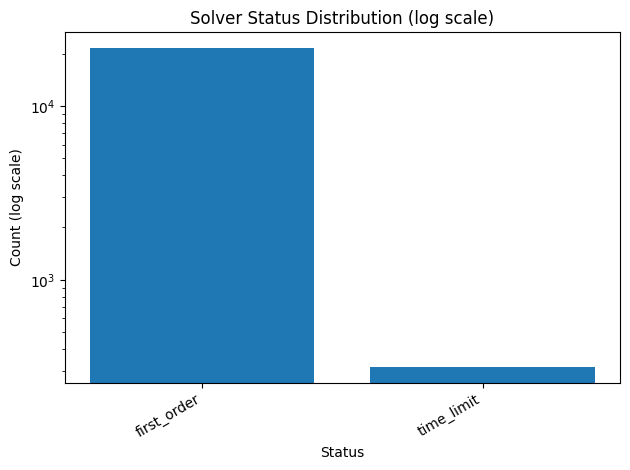

In [ ]:
plt.figure()
plt.bar(status_table["status"], status_table["count"])
plt.yscale("log")
plt.xlabel("Status")
plt.ylabel("Count (log scale)")
plt.title("Solver Status Distribution (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

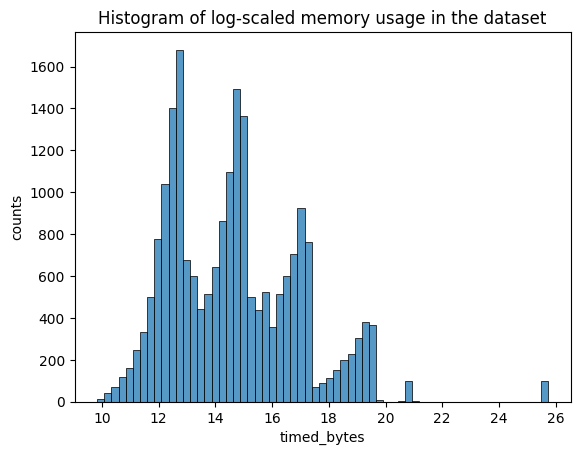

In [ ]:
x = data["timed_bytes"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.ylabel("counts")
plt.title("Histogram of log-scaled memory usage in the dataset")
plt.show()

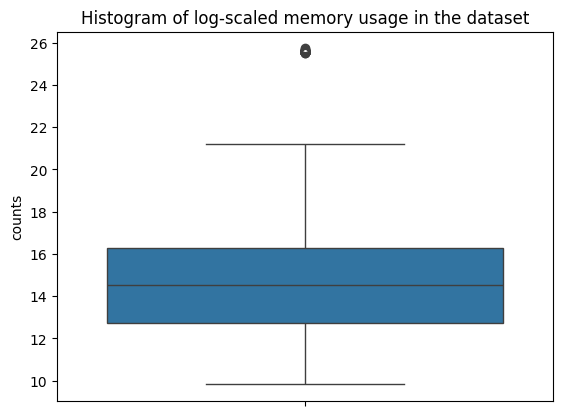

In [ ]:
x = data["timed_bytes"]
x.describe()

sns.boxplot(y=np.log1p(x))
plt.ylabel("counts")
plt.title("Histogram of log-scaled memory usage in the dataset")
plt.show()

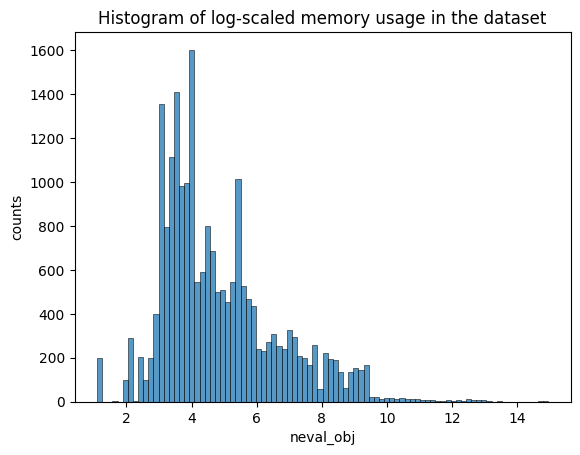

In [ ]:
x = data["neval_obj"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.ylabel("counts")
plt.title("Histogram of log-scaled memory usage in the dataset")
plt.show()

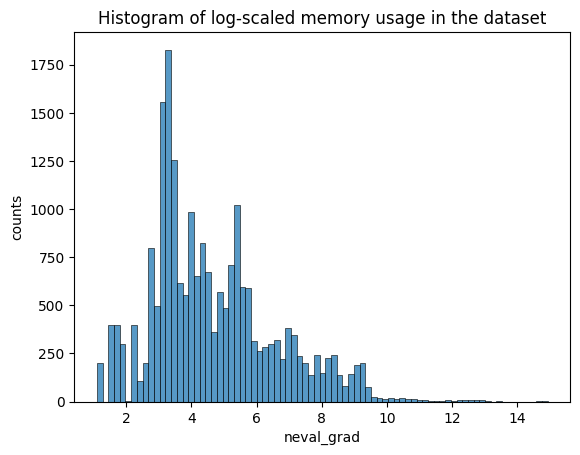

In [ ]:
x = data["neval_grad"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.ylabel("counts")
plt.title("Histogram of log-scaled memory usage in the dataset")
plt.show()

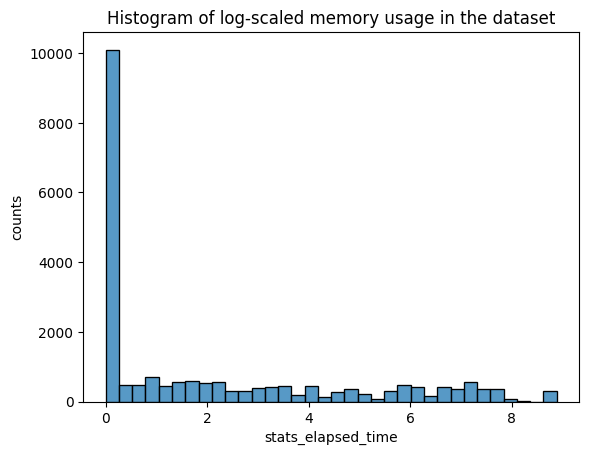

In [ ]:
x = data["stats_elapsed_time"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.ylabel("counts")
plt.title("Histogram of log-scaled memory usage in the dataset")
plt.show()

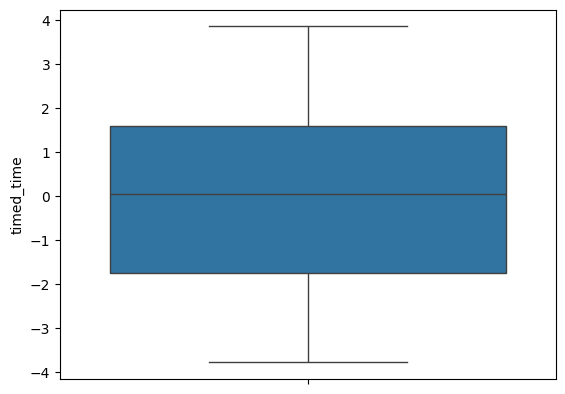

In [ ]:
x = data["timed_time"]
x.describe()

sns.boxplot(y=np.log10(x))
plt.ylabel("timed_time")
plt.show()

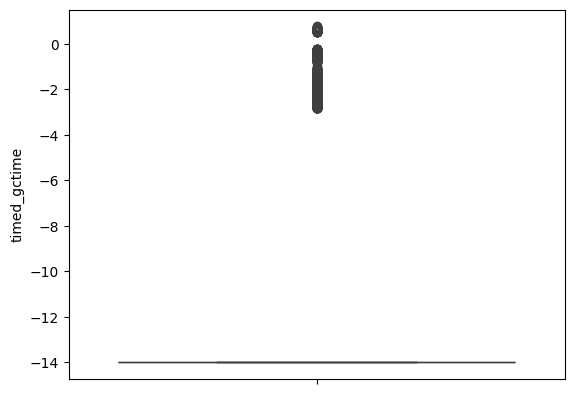

In [ ]:
x = data["timed_gctime"]
x.describe()

sns.boxplot(y=np.log10(x + 0.00000000000001))
plt.ylabel("timed_gctime")
plt.show()

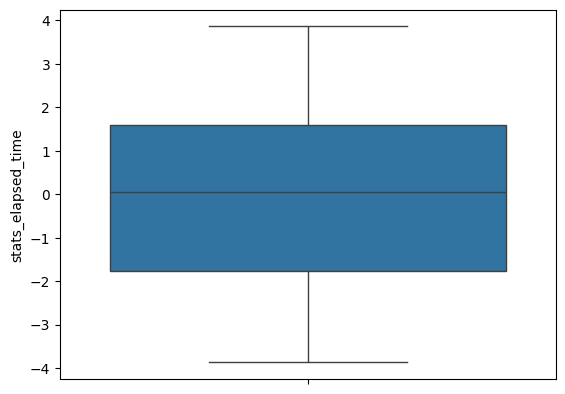

In [ ]:
x = data["stats_elapsed_time"]
x.describe()

sns.boxplot(y=np.log10(x))
plt.ylabel("stats_elapsed_time")
plt.show()

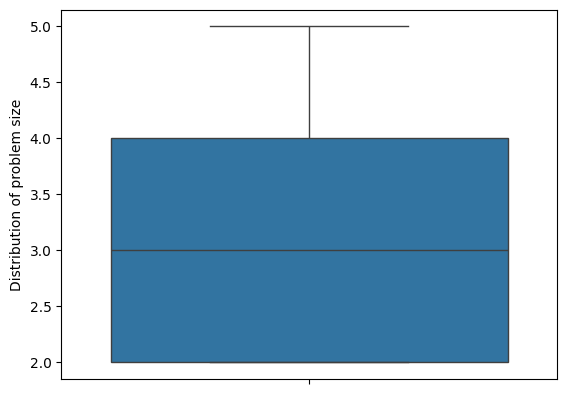

In [ ]:
x = data["nvar"]
x.describe()

sns.boxplot(y=np.log10(x))
plt.xlabel("Distribution of problem size")
plt.show()

In [ ]:
data["nvar"].value_counts()

nvar
100       6404
1000      5916
10000     3473
100000    2145
99        1200
999       1200
9999      1104
961        300
99999       48
99856       12
Name: count, dtype: int64

In [ ]:
intervals = [100, 1000, 10000, 100000]
data["nvar"] = data["nvar"].apply(lambda x: min(intervals, key=lambda i: abs(i - x)))

In [ ]:
data["nvar"].value_counts()

nvar
100       7604
1000      7416
10000     4577
100000    2205
Name: count, dtype: int64

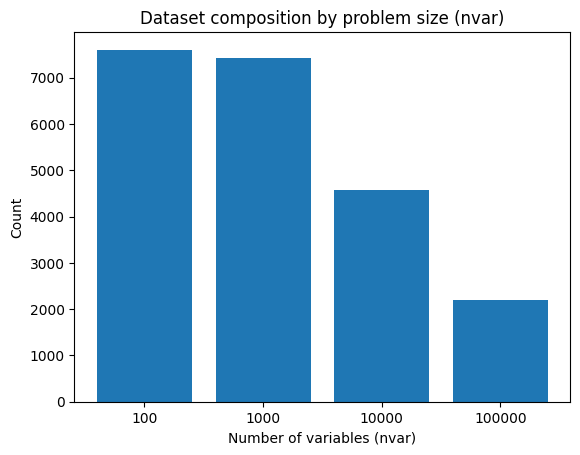

In [ ]:
counts = data["nvar"].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Number of variables (nvar)")
plt.ylabel("Count")
plt.title("Dataset composition by problem size (nvar)")
plt.show()

0        OptimizationProb...
1        OptimizationProb...
2        OptimizationProb...
3        OptimizationProb...
4        OptimizationProb...
                ...         
21797    OptimizationProb...
21798    OptimizationProb...
21799    OptimizationProb...
21800    OptimizationProb...
21801    OptimizationProb...
Name: problem, Length: 21802, dtype: object